In [1]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight, resample


In [2]:
CSV_PATH = "D:/BreastCancerDetectionDataset/train/train.csv"
IMAGE_DIR = "D:/BreastCancerDetectionDataset/mammos/"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

In [3]:
# Load dataset
train_df = pd.read_csv(CSV_PATH)

In [4]:
# Validate images exist
valid_rows = []
for index, row in train_df.iterrows():
    image_path = os.path.join(IMAGE_DIR, f"{row['patient_id']}_{row['image_id']}.png")
    if os.path.exists(image_path):
        valid_rows.append([image_path, row['cancer']])

train_df = pd.DataFrame(valid_rows, columns=['image_path', 'cancer'])
train_df['cancer'] = train_df['cancer'].astype(int)


In [5]:
# Handle class imbalance by oversampling cancerous images
cancer_df = train_df[train_df['cancer'] == 1]
non_cancer_df = train_df[train_df['cancer'] == 0]

if len(cancer_df) < len(non_cancer_df):
    cancer_df = resample(cancer_df, replace=True, n_samples=len(non_cancer_df), random_state=42)
    train_df = pd.concat([cancer_df, non_cancer_df]).sample(frac=1).reset_index(drop=True)


In [6]:
# Split data
train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df['cancer'], random_state=42)
train_df['cancer'] = train_df['cancer'].astype(str)
val_df['cancer'] = val_df['cancer'].astype(str)


In [7]:
# Image augmentation
train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, rotation_range=20, zoom_range=0.2)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(train_df, x_col='image_path', y_col='cancer',
                                                     target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')
val_generator = val_datagen.flow_from_dataframe(val_df, x_col='image_path', y_col='cancer',
                                                 target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')


Found 85670 validated image filenames belonging to 2 classes.
Found 21418 validated image filenames belonging to 2 classes.


In [8]:
# Build model
model = Sequential([
    Input(shape=(224, 224, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Compute class weights
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(train_df['cancer'].astype(int)),
                                                  y=train_df['cancer'].astype(int))
class_weights = dict(enumerate(class_weights))


In [10]:
# Train model with class weights
history = model.fit(train_generator, validation_data=val_generator, epochs=EPOCHS, class_weight=class_weights)


C:\Users\paul9\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
2678/2678 ━━━━━━━━━━━━━━━━━━━━ 7295s 3s/step - accuracy: 0.5553 - loss: 0.6842 - val_accuracy: 0.5866 - val_loss: 0.6656
Epoch 2/10
2678/2678 ━━━━━━━━━━━━━━━━━━━━ 8337s 3s/step - accuracy: 0.5933 - loss: 0.6610 - val_accuracy: 0.6255 - val_loss: 0.6328
Epoch 3/10
2678/2678 ━━━━━━━━━━━━━━━━━━━━ 6763s 3s/step - accuracy: 0.6287 - loss: 0.6336 - val_accuracy: 0.6600 - val_loss: 0.6076
Epoch 4/10
2678/2678 ━━━━━━━━━━━━━━━━━━━━ 5074s 2s/step - accuracy: 0.6500 - loss: 0.6126 - val_accuracy: 0.6892 - val_loss: 0.5763
Epoch 5/10
2678/2678 ━━━━━━━━━━━━━━━━━━━━ 5115s 2s/step - accuracy: 0.6696 - loss: 0.5970 - val_accuracy: 0.7041 - val_loss: 0.5643
Epoch 6/10
2678/2678 ━━━━━━━━━━━━━━━━━━━━ 5037s 2s/step - accuracy: 0.6867 - loss: 0.5767 - val_accuracy: 0.7289 - val_loss: 0.5304
Epoch 7/10
2678/2678 ━━━━━━━━━━━━━━━━━━━━ 6687s 2s/step - accuracy: 0.7045 - loss: 0.5573 - val_accuracy: 0.7351 - val_loss: 0.5276
Epoch 8/10
2678/2678 ━━━━━━━━━━━━━━━━━━━━ 6942s 3s/step - accuracy: 0.7231 -

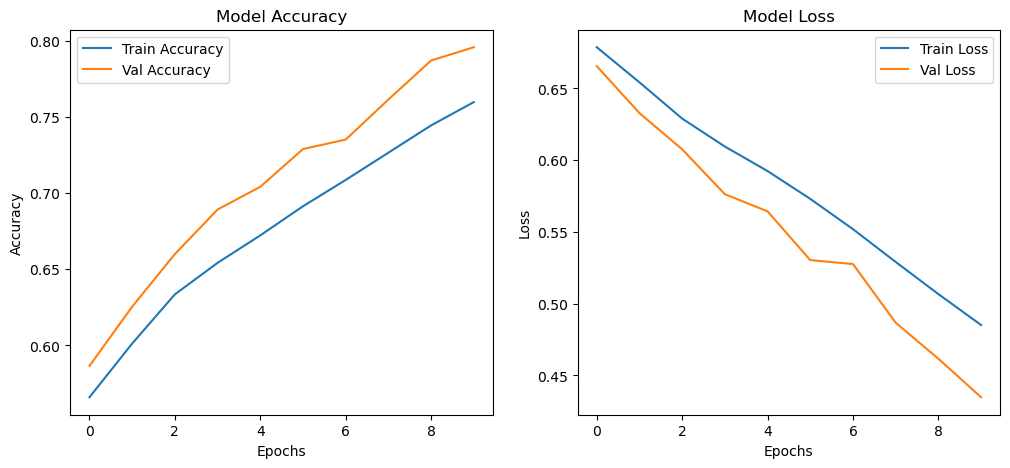

In [11]:
# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [13]:
# Evaluate model
test_loss, test_acc = model.evaluate(val_generator)
print(f"Validation Accuracy: {test_acc:.4f}")
print(f"Validation Loss: {test_loss:.4f}")


670/670 ━━━━━━━━━━━━━━━━━━━━ 260s 388ms/step - accuracy: 0.7991 - loss: 0.4314
Validation Accuracy: 0.7957
Validation Loss: 0.4348


In [14]:
# Prediction function
def predict_image(image_path, model, threshold=0.5):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    prediction = model.predict(img)[0][0]
    label = "Cancer Detected" if prediction > threshold else "No Cancer"
    confidence = prediction if prediction > threshold else 1 - prediction
    print(f"Prediction: {label} ({confidence:.2f})")


In [15]:
# Save model
model.save("breast_cancer_detection_model.h5")


In [16]:
sample_image = "D:/BreastCancerDetectionDataset/test/938/938_282960859.png"


In [17]:
def predict_image(image_path, model, threshold=0.3):  # Lower threshold to 0.3
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)[0][0]
    label = "Cancer Detected" if prediction > threshold else "No Cancer"
    confidence = prediction if prediction > threshold else 1 - prediction

    print(f"Prediction: {label} ({confidence:.2f})")


In [48]:
sample_image = "D:/BreastCancerDetectionDataset/test/test14.png"  # Ensure correct path

In [49]:
predict_image(sample_image, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
Prediction: Cancer Detected (0.59)
